# Week 8 Activity: Onset Detection and Autocorrelation

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In [61]:
import numpy as np
import scipy
from scipy.io.wavfile import read
from scipy import signal
import matplotlib.pyplot as plt
from IPython.display import Audio
import librosa, librosa.display
from librosa import feature, frames_to_time, autocorrelate, clicks, display
import typing
from typing import Counter

## Onset Detection

Read in the following files below, and normalize.

a) 80sPopDrums.wav  
b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
c) prelude_cmaj_10s.wav  

In [62]:
from scipy.io.wavfile import read
(fs, pop) = read('../Audio/80sPopDrums.wav')

(fs2, black_keys) = read('../Audio/TheBlackKeys_track4.wav')
max_start_frame = black_keys.shape[0] - int(10*fs)
random = np.random.default_rng()
start = random.integers(500, max_start_frame)
end = start + int(10*fs)
random_black_keys = black_keys[start:end]

prelude, fs3 = librosa.load('../Audio/prelude_cmaj_10s.wav', mono=False)
prelude_mono = librosa.to_mono(prelude)


#### For each of the tracks (start with just one):

1) Compute the energy and RMSE for each track using a frame length of your choice  
2) Plot the energy and the RMSE
3) Use one of the energy features to create your novelty function and plot
4) Write a peak picking function to define onsets from your novelty function
4) Based on the plots, estimate what an appropriate 'threshold' would be. Does the threshold change across tracks? If so, what could you do to put them on a similar scale?

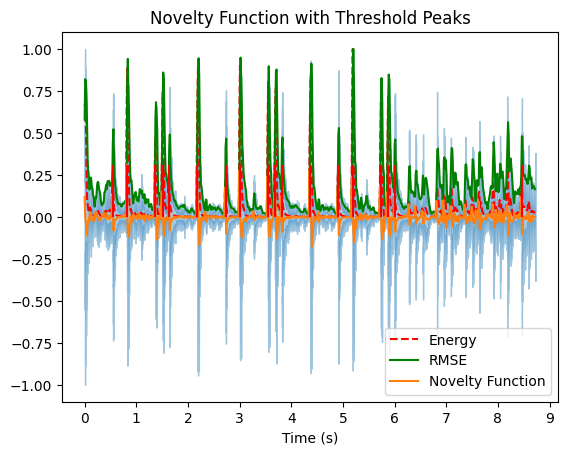

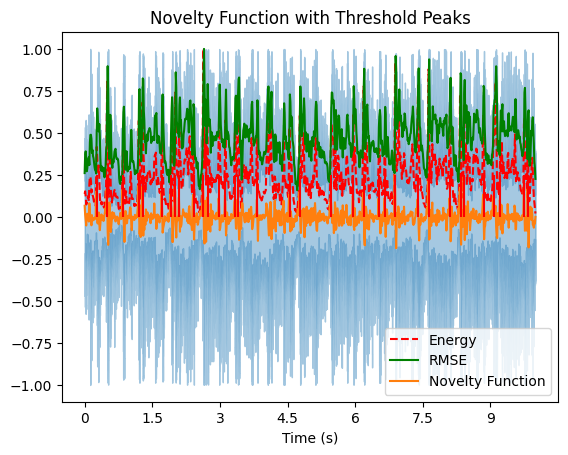

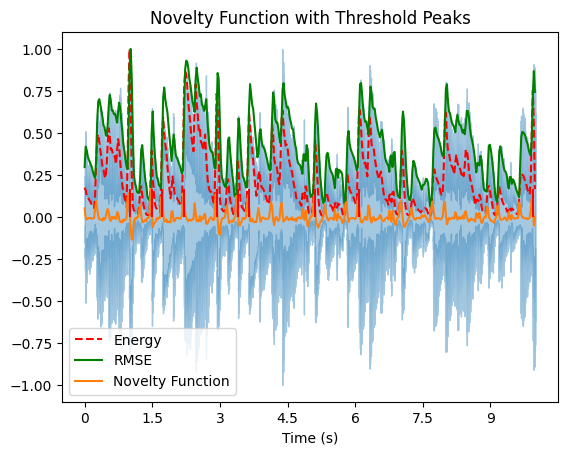

In [63]:
## TRACK ONE
###################################
dur = pop.size/fs
time = np.arange(0, dur, 1/fs)
pop_norm = pop/np.abs(pop.max())

hop_length = 512
frame_length = 1024

energy = np.array([
    sum(abs(pop_norm[i:i+frame_length]**2)) for i in range(0, len(pop_norm), hop_length)
])

rmse = librosa.feature.rms(y = pop_norm, frame_length=frame_length, hop_length=hop_length, center=True)
frames = range(len(energy))
t = librosa.frames_to_time(frames, sr=fs, hop_length=hop_length)
librosa.display.waveshow(pop_norm, sr=fs, alpha=0.4)
plt.plot(t, energy/energy.max(), 'r--', label='Energy')       
plt.plot(t, rmse[0]/rmse[0].max(), color='g', label='RMSE')   
plt.title('Normalized Signal with Energy and RMS overlaid')
plt.legend()

rmse_diff = np.diff(rmse[0])
novelty = np.concatenate((rmse_diff, np.array([0])))  

threshold = 0.1
peak_indices = []

for i in range(1, len(novelty)-1):
    if novelty[i] > threshold:
        if novelty[i] > novelty[i-1] and novelty[i] > novelty[i+1]:
            peak_indices.append(i)

peaks, properties = signal.find_peaks(novelty, height=0.1)
peak_times = t[1:][peaks]

plt.plot(t, novelty, label='Novelty Function')
plt.vlines(peak_times, 0, np.max(novelty), colors='r')
plt.xlabel('Time (s)')
plt.title('Novelty Function with Threshold Peaks')
plt.legend()
plt.show()

## TRACK TWO
###################################

dur = random_black_keys.size/fs2
time = np.arange(0, dur, 1/fs2)
black_keys_norm = random_black_keys/np.abs(random_black_keys.max())

hop_length = 512
frame_length = 1024

energy = np.array([
    sum(abs(black_keys_norm[i:i+frame_length]**2)) for i in range(0, len(black_keys_norm), hop_length)
])

rmse = librosa.feature.rms(y = black_keys_norm, frame_length=frame_length, hop_length=hop_length, center=True)
frames = range(len(energy))
t = librosa.frames_to_time(frames, sr=fs, hop_length=hop_length)
librosa.display.waveshow(black_keys_norm, sr=fs, alpha=0.4)
plt.plot(t, energy/energy.max(), 'r--', label='Energy')       
plt.plot(t, rmse[0]/rmse[0].max(), color='g', label='RMSE')   
plt.title('Normalized Signal with Energy and RMS overlaid')
plt.legend()

rmse_diff = np.diff(rmse[0])
novelty2 = np.concatenate((rmse_diff, np.array([0])))  

threshold = 0.1
peak_indices = []

for i in range(1, len(novelty2)-1):
    if novelty2[i] > threshold:
        if novelty2[i] > novelty2[i-1] and novelty2[i] > novelty2[i+1]:
            peak_indices.append(i)

peaks, properties = signal.find_peaks(novelty2, height=0.1)
peak_times = t[1:][peaks]

plt.plot(t, novelty2, label='Novelty Function')
plt.vlines(peak_times, 0, np.max(novelty2), colors='r')
plt.xlabel('Time (s)')
plt.title('Novelty Function with Threshold Peaks')
plt.legend()
plt.show()

## TRACK THREE
###################################

dur = prelude_mono.size/fs3
time = np.arange(0, dur, 1/fs3)
prelude_norm = prelude_mono/np.abs(prelude_mono.max())

hop_length = 512
frame_length = 1024

energy = np.array([
    sum(abs(prelude_norm[i:i+frame_length]**2)) for i in range(0, len(prelude_norm), hop_length)
])

rmse = librosa.feature.rms(y = prelude_norm, frame_length=frame_length, hop_length=hop_length, center=True)
frames = range(len(energy))
t = librosa.frames_to_time(frames, sr=fs3, hop_length=hop_length)
librosa.display.waveshow(prelude_norm, sr=fs3, alpha=0.4)
plt.plot(t, energy/energy.max(), 'r--', label='Energy')       
plt.plot(t, rmse[0]/rmse[0].max(), color='g', label='RMSE')
plt.title('Normalized Signal with Energy and RMS overlaid')
plt.legend()

rmse_diff = np.diff(rmse[0])
novelty3 = np.concatenate((rmse_diff, np.array([0])))  

threshold = 0.1
peak_indices = []

for i in range(1, len(novelty3)-1):
    if novelty3[i] > threshold:
        if novelty3[i] > novelty3[i-1] and novelty3[i] > novelty3[i+1]:
            peak_indices.append(i)

peaks, properties = signal.find_peaks(novelty3, height=0.1)
peak_times = t[1:][peaks]

plt.plot(t, novelty3, label='Novelty Function')
plt.vlines(peak_times, 0, np.max(novelty3), colors='r')
plt.xlabel('Time (s)')
plt.title('Novelty Function with Threshold Peaks')
plt.legend()
plt.show()


## Tempo Estimation

Using your novelty functions and detected onsets above, estimate the global tempo of the files using autocorrelation and IOIs.

1) IOI Based Tempo

- Compute Inter-Onset Intervals (IOIs)
- Convert IOIs to BPM
- Create a beat histogram to help you infer tempos

2) Autocorrelation based Tempo
- Compute the autocorrelation of your novelty function
- Convert lag to BPMs (conside perceptual relevance)
- Crate a beat histogram to help you infer tempos

[(0.4876190476190476, 2), (0.23219954648526064, 1), (0.7198185941043085, 1)]
109.89010989010988 468.75 431.65467625899277


Text(0.5, 1.0, 'Beat Histogram (Autocorrelation)')

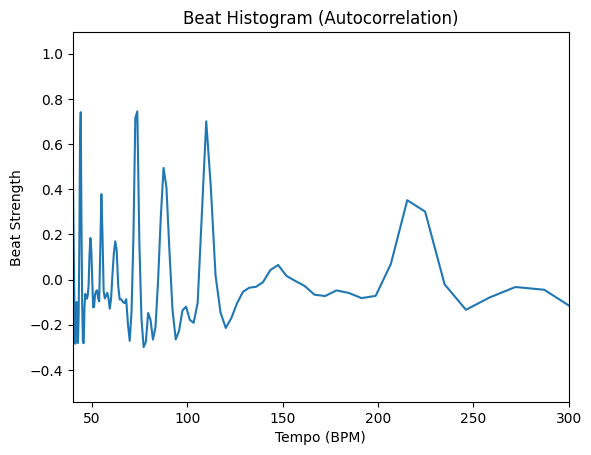

In [64]:
# 1. IOI:

iois = np.diff(peak_times)

num_counts = Counter(iois)
top_n = num_counts.most_common(3)

print(top_n)

tempo1 = 60 / 0.546
tempo2 = 60 / 0.128
tempo3 = 60 / .139

print(tempo1, tempo2, tempo3)

###############

# 2. Autocorrelation:

ac = librosa.autocorrelate(novelty)
ac = ac / ac.max()
lags = np.arange(len(ac))
points = np.where(ac > 0.3) # ignore zero and one indices
points = np.array(points)
t_inc = hop_length * points / fs
#ignore first two values (zero and one)
t_inc[0][2:]
#calculate the differences between the values
ts = t_inc[0][2:]

durs = ts[1:] - ts[:-1]
durs = np.round(durs, 3) # round to 3 decimal places
num_counts = Counter(durs)
top_n = num_counts.most_common(3)

tempa = 60 / top_n[0][0]
tempb = 60 / top_n[1][0]
tempc = 60 / top_n[2][0]

# print( tempa, tempb, tempc)
ac = librosa.autocorrelate(novelty)
lags = np.arange(len(ac))
lag_times = lags * hop_length / fs
bpms = 60 / lag_times[1:]   # avoid divide by zero
strength = ac[1:]

plt.plot(bpms, strength)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram (Autocorrelation)")


Estimate tempo using librosa.beat.tempo. How do your results compare?

Between autocorrelation and IOIs, which method is most stable? Which is most sensitive to onset errors? Do the different files present different behaviors/accuracies?

///////////////////////////////////////////////////////////////////////////

Autocorrelation is the far more stable method because of it's usefulness in all environments. It can be used far beyond tempo and pitch and go into meter detection and loop point detection. IOI series is most sensitive to onset errors, to the point that autocorrelation is often used to analyze the stability of the IOI. 

///////////////////////////////////////////////////////////////////////////

## Extension

Repeat the activities above but change the frame size and hop length. How does that impact your results?